# 04b - Macro GNN-Correlation Multi-Window Hyperparameter Search

Validation-only hyperparameter search for the 21d, 63d, and 126d macro correlation GNNs.

This notebook is designed for an overnight run. It is resume-safe at the configuration level: if a config's checkpoint, validation-loss JSON, and search record already exist, that config is skipped on rerun. Each window writes separate per-config checkpoints, a separate best checkpoint, validation/test predictions for the selected model, and a compact aggregate summary.


In [1]:
from __future__ import annotations

import json
import shutil
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'config.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config
from src.experiment_registry import register_experiment
from src.models import GNNModelV2
from src.train import predict_gnn_split, set_seeds, train_gnn

pd.set_option('display.max_columns', 120)

WINDOWS = [21, 63, 126]
THRESHOLD = config.CORR_THRESHOLD
FEATURE_VERSION = 'stock_features_plus_regime_v1'
FEATURE_PATH = Path(config.DATA_FEATURES_DIR) / 'features_macro.parquet'
META_PATH = Path(config.DATA_FEATURES_DIR) / 'features_macro_meta.json'
WINDOW_EDGE_DIR = Path(config.DATA_GRAPHS_DIR) / 'corr_edges_window'
RESULTS_DIR = Path(config.DATA_RESULTS_DIR)
CHECKPOINT_DIR = Path(config.CHECKPOINTS_DIR)
SUMMARY_JSON_PATH = RESULTS_DIR / 'gnn_corr_macro_multi_window_hparam_summary.json'
SUMMARY_CSV_PATH = RESULTS_DIR / 'gnn_corr_macro_multi_window_hparam_summary.csv'

# Keep this True for the overnight run. Rerunning is safe; completed configs are skipped.
RUN_SEARCH = True
GENERATE_PREDICTIONS = True
REGISTER_BEST_MODELS = True

# Base grid reproduces the prior macro correlation search axes.
HPARAM_GRID = {
    'hidden_dim': [128, 256],
    'dropout': [0.1, 0.3, 0.5],
    'lr': [3e-4, 1e-3],
    'num_layers': [2, 3],
    'batch_norm': [False, True],
}

# Targeted additions based on prior searches:
# - interpolate lr with 5e-4 rather than revisit weak 1e-4 runs;
# - probe dropout=0.2 near the best 0.1/0.3 region, not more high-dropout values;
# - try hidden_dim=384 only near strong configs;
# - try num_layers=1 for shorter/noisier windows where message passing may over-smooth.
EXTRA_HPARAM_CONFIGS = [
    {'lr': 5e-4, 'hidden_dim': 256, 'dropout': 0.3, 'batch_norm': True,  'num_layers': 3},
    {'lr': 5e-4, 'hidden_dim': 256, 'dropout': 0.3, 'batch_norm': False, 'num_layers': 3},
    {'lr': 5e-4, 'hidden_dim': 256, 'dropout': 0.3, 'batch_norm': True,  'num_layers': 2},
    {'lr': 5e-4, 'hidden_dim': 256, 'dropout': 0.3, 'batch_norm': False, 'num_layers': 2},
    {'lr': 3e-4, 'hidden_dim': 256, 'dropout': 0.2, 'batch_norm': True,  'num_layers': 3},
    {'lr': 5e-4, 'hidden_dim': 256, 'dropout': 0.2, 'batch_norm': True,  'num_layers': 3},
    {'lr': 3e-4, 'hidden_dim': 256, 'dropout': 0.2, 'batch_norm': False, 'num_layers': 2},
    {'lr': 5e-4, 'hidden_dim': 256, 'dropout': 0.2, 'batch_norm': False, 'num_layers': 2},
    {'lr': 3e-4, 'hidden_dim': 384, 'dropout': 0.3, 'batch_norm': True,  'num_layers': 3},
    {'lr': 5e-4, 'hidden_dim': 384, 'dropout': 0.3, 'batch_norm': True,  'num_layers': 3},
    {'lr': 3e-4, 'hidden_dim': 384, 'dropout': 0.3, 'batch_norm': False, 'num_layers': 2},
    {'lr': 5e-4, 'hidden_dim': 384, 'dropout': 0.3, 'batch_norm': False, 'num_layers': 2},
    {'lr': 3e-4, 'hidden_dim': 256, 'dropout': 0.1, 'batch_norm': False, 'num_layers': 1},
    {'lr': 1e-3, 'hidden_dim': 256, 'dropout': 0.1, 'batch_norm': False, 'num_layers': 1},
    {'lr': 3e-4, 'hidden_dim': 256, 'dropout': 0.3, 'batch_norm': False, 'num_layers': 1},
    {'lr': 1e-3, 'hidden_dim': 256, 'dropout': 0.3, 'batch_norm': False, 'num_layers': 1},
]

WINDOW_EDGE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root:    {PROJECT_ROOT}')
print(f'Windows:         {WINDOWS}')
print(f'Threshold:       {THRESHOLD}')
print(f'Feature version: {FEATURE_VERSION}')
print(f'Feature path:    {FEATURE_PATH}')
print(f'Window edge dir: {WINDOW_EDGE_DIR}')
print(f'Run search:      {RUN_SEARCH}')


Project root:    C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project
Windows:         [21, 63, 126]
Threshold:       0.3
Feature version: stock_features_plus_regime_v1
Feature path:    C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\features\features_macro.parquet
Window edge dir: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\graphs\corr_edges_window
Run search:      True


In [2]:
# Load macro features, target, and splits.
target = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'target.parquet')
splits = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'splits.parquet')
target.index = pd.to_datetime(target.index)
splits['week'] = pd.to_datetime(splits['week'])
tickers = target.columns.tolist()

with open(META_PATH, encoding='utf-8') as fh:
    meta = json.load(fh)
feature_names = meta['feature_names']
assert meta.get('feature_version') == FEATURE_VERSION, meta.get('feature_version')

feat_df = pd.read_parquet(FEATURE_PATH)
feat_df['week'] = pd.to_datetime(feat_df['week'])
feat_df = feat_df[feat_df['week'].isin(target.index)].copy()

ticker_order = {ticker: i for i, ticker in enumerate(tickers)}
feat_df['_ord'] = feat_df['ticker'].map(ticker_order)
feat_df = feat_df.sort_values(['week', '_ord']).drop(columns='_ord')

n_weeks = target.shape[0]
n_stocks = target.shape[1]
n_feats = len(feature_names)
features_3d = feat_df[feature_names].to_numpy(dtype=float).reshape(n_weeks, n_stocks, n_feats)
target_arr = target.to_numpy(dtype=float)
week_index = pd.DatetimeIndex(target.index)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

assert features_3d.shape == (n_weeks, n_stocks, n_feats)
assert target_arr.shape == (n_weeks, n_stocks)
assert list(feat_df.loc[feat_df['week'].eq(week_index[0]), 'ticker']) == tickers

print(f'features_3d: {features_3d.shape}  target_arr: {target_arr.shape}')
print(f'tickers: {len(tickers)}  n_feats: {n_feats}  device: {device}')
print('Regime features:', meta.get('regime_feature_names', []))


features_3d: (572, 465, 19)  target_arr: (572, 465)
tickers: 465  n_feats: 19  device: cuda
Regime features: ['vix_level', 'vix_change_1w', 'spy_rv_21d', 'spy_return_1w', 'spy_return_1m', 'treasury_10y_2y_spread', 'ig_credit_spread', 'avg_pairwise_stock_correlation', 'correlation_graph_density']


In [3]:
# Artifact naming and window graph loading.
def threshold_tag(threshold: float) -> str:
    return 't' + f'{threshold:.1f}'.replace('.', 'p')


def window_tag(window: int) -> str:
    return f'w{window:03d}'


def edge_path(split: str, window: int, threshold: float = THRESHOLD) -> Path:
    return WINDOW_EDGE_DIR / f'corr_edges_{split}_{threshold_tag(threshold)}_{window_tag(window)}.parquet'


def graph_version(window: int, threshold: float = THRESHOLD) -> str:
    return f'correlation_threshold_{threshold}_lookback_{window}'


def window_run_prefix(window: int) -> str:
    return f'corr_macro_{window_tag(window)}_hparam'


def window_results_path(window: int) -> Path:
    return RESULTS_DIR / f'gnn_corr_macro_{window_tag(window)}_hparam_search_results.json'


def window_best_checkpoint_name(window: int) -> str:
    return f'gnn_corr_macro_{window_tag(window)}_hparam_best.pt'


def window_val_pred_path(window: int) -> Path:
    return RESULTS_DIR / f'gnn_corr_macro_{window_tag(window)}_hparam_val_preds.parquet'


def window_test_pred_path(window: int) -> Path:
    return RESULTS_DIR / f'test_preds_gnn_corr_macro_{window_tag(window)}_hparam.parquet'


def load_window_graphs(window: int, split_name: str, threshold: float = THRESHOLD) -> dict[pd.Timestamp, torch.LongTensor]:
    path = edge_path(split_name, window, threshold)
    if not path.exists():
        raise FileNotFoundError(f'Missing {path}. Run notebooks/04e_corr_window_models.ipynb graph precompute first.')
    df = pd.read_parquet(path)
    graphs = {}
    for week_str, group in df.groupby('week', sort=True):
        graphs[pd.Timestamp(week_str)] = torch.tensor(
            np.vstack([group['src'].to_numpy(np.int64), group['dst'].to_numpy(np.int64)]),
            dtype=torch.long,
        )
    return graphs


artifact_plan = pd.DataFrame([
    {
        'window': window,
        'graph_version': graph_version(window),
        'search_results': window_results_path(window).as_posix(),
        'best_checkpoint': (CHECKPOINT_DIR / window_best_checkpoint_name(window)).as_posix(),
        'val_predictions': window_val_pred_path(window).as_posix(),
        'test_predictions': window_test_pred_path(window).as_posix(),
    }
    for window in WINDOWS
])
display(artifact_plan)


,window,graph_version,search_results,best_checkpoint,val_predictions,test_predictions
0,21,correlation_threshold_0.3_lookback_21,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...
1,63,correlation_threshold_0.3_lookback_63,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...
2,126,correlation_threshold_0.3_lookback_126,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...


In [4]:
# Build the validation-only macro hparam grid.
base_grid = [
    {
        'lr': lr,
        'hidden_dim': hidden_dim,
        'dropout': dropout,
        'batch_norm': batch_norm,
        'num_layers': num_layers,
        'config_source': 'base_grid',
    }
    for lr in HPARAM_GRID['lr']
    for hidden_dim in HPARAM_GRID['hidden_dim']
    for dropout in HPARAM_GRID['dropout']
    for batch_norm in HPARAM_GRID['batch_norm']
    for num_layers in HPARAM_GRID['num_layers']
]
extra_grid = [{**cfg, 'config_source': 'targeted_extra'} for cfg in EXTRA_HPARAM_CONFIGS]

grid = []
seen = set()
for cfg in [*base_grid, *extra_grid]:
    key = (float(cfg['lr']), int(cfg['hidden_dim']), float(cfg['dropout']), bool(cfg['batch_norm']), int(cfg['num_layers']))
    if key in seen:
        continue
    seen.add(key)
    grid.append(cfg)

grid_df = pd.DataFrame(grid)
grid_df.index.name = 'config_idx'

print(f'Base Cartesian configs: {len(base_grid)}')
print(f'Targeted extra configs before de-duplication: {len(extra_grid)}')
print(f'Total configs per window after de-duplication: {len(grid)}')
print(f'Total training runs if nothing is cached: {len(grid) * len(WINDOWS)}')
print('Base grid axes:')
for key, values in HPARAM_GRID.items():
    print(f'  {key:<10}: {values}')
print('Targeted additions: lr=5e-4, dropout=0.2, hidden_dim=384 near strong configs, and num_layers=1 probes.')
print(f'  patience  : {config.GNN_HPARAM_PATIENCE} epochs')
print(f'  max_epochs: {config.GNN_MAX_EPOCHS}')
display(grid_df)


Base Cartesian configs: 48
Targeted extra configs before de-duplication: 16
Total configs per window after de-duplication: 64
Total training runs if nothing is cached: 192
Base grid axes:
  hidden_dim: [128, 256]
  dropout   : [0.1, 0.3, 0.5]
  lr        : [0.0003, 0.001]
  num_layers: [2, 3]
  batch_norm: [False, True]
Targeted additions: lr=5e-4, dropout=0.2, hidden_dim=384 near strong configs, and num_layers=1 probes.
  patience  : 7 epochs
  max_epochs: 150


,lr,hidden_dim,dropout,batch_norm,num_layers,config_source
config_idx,,,,,,
0,0.0003,128,0.1,False,2,base_grid
1,0.0003,128,0.1,False,3,base_grid
2,0.0003,128,0.1,True,2,base_grid
3,0.0003,128,0.1,True,3,base_grid
4,0.0003,128,0.3,False,2,base_grid
...,...,...,...,...,...,...
59,0.0005,384,0.3,False,2,targeted_extra
60,0.0003,256,0.1,False,1,targeted_extra
61,0.0010,256,0.1,False,1,targeted_extra


In [5]:
def load_window_graph_bundle(window: int, splits_to_load=('train', 'val')) -> dict[pd.Timestamp, torch.LongTensor]:
    graphs = {}
    for split_name in splits_to_load:
        graphs.update(load_window_graphs(window, split_name))
    return graphs


def read_completed_window_runs(results_path: Path) -> dict[int, dict]:
    if not results_path.exists():
        return {}
    with open(results_path, encoding='utf-8') as fh:
        saved = json.load(fh)
    completed = {}
    for entry in saved.get('runs', []):
        completed[int(entry['config_idx'])] = entry
    return completed


def run_one_window_hparam_search(
    window: int,
    features,
    target_array,
    week_index,
    splits_df,
    grid_configs,
    device,
) -> tuple[pd.DataFrame, dict]:
    run_prefix = window_run_prefix(window)
    results_path = window_results_path(window)
    completed = read_completed_window_runs(results_path)
    graphs = load_window_graph_bundle(window, ('train', 'val'))
    edge_fn = lambda week, g=graphs: g.get(week, torch.zeros(2, 0, dtype=torch.long))

    run_records = []
    print('\n' + '#' * 80)
    print(f'Window {window}d search ({graph_version(window)})')
    print(f'Existing completed records: {len(completed)}')

    for i, cfg in enumerate(grid_configs):
        graph_tag = f'{run_prefix}_{i:03d}'
        ckpt_path = CHECKPOINT_DIR / f'gnn_{graph_tag}_best.pt'
        loss_path = RESULTS_DIR / f'gnn_{graph_tag}_val_loss.json'

        print('\n' + '=' * 72)
        print(f'Window {window}d | Config {i + 1}/{len(grid_configs)} [{graph_tag}]')
        print(
            f"  lr={cfg['lr']}  hidden={cfg['hidden_dim']}  dropout={cfg['dropout']}  "
            f"batch_norm={cfg['batch_norm']}  num_layers={cfg['num_layers']}"
        )

        if i in completed and ckpt_path.exists() and loss_path.exists():
            saved_entry = completed[i]
            val_mse = float(saved_entry['val_mse'])
            print(f'  Already done; val MSE={val_mse:.6f} (skipping)')
            run_records.append(saved_entry)
            continue

        set_seeds()
        model = GNNModelV2(
            in_channels=features.shape[2],
            hidden_dim=int(cfg['hidden_dim']),
            dropout=float(cfg['dropout']),
            num_layers=int(cfg['num_layers']),
            batch_norm=bool(cfg['batch_norm']),
        ).to(device)
        print(f'  Parameters: {sum(p.numel() for p in model.parameters()):,}')

        train_gnn(
            model=model,
            features=features,
            target=target_array,
            week_index=week_index,
            edge_index_fn=edge_fn,
            splits=splits_df,
            graph_type=graph_tag,
            device=device,
            max_epochs=config.GNN_MAX_EPOCHS,
            lr=float(cfg['lr']),
            patience=config.GNN_HPARAM_PATIENCE,
            save_periodic=False,
        )

        with open(loss_path, encoding='utf-8') as fh:
            loss_data = json.load(fh)
        val_mse = float(loss_data['best_val_loss'])
        record = {
            **cfg,
            'window': window,
            'config_idx': i,
            'val_mse': val_mse,
            'checkpoint': str(ckpt_path),
            'validation_metrics_path': str(loss_path),
        }
        run_records.append(record)
        print(f'  Best val MSE={val_mse:.6f}')

        with open(results_path, 'w', encoding='utf-8') as fh:
            json.dump(
                {
                    'window': window,
                    'feature_version': FEATURE_VERSION,
                    'graph_version': graph_version(window),
                    'runs': run_records,
                },
                fh,
                indent=2,
            )

    results = pd.DataFrame(run_records).sort_values('val_mse').reset_index(drop=True)
    best_row = results.iloc[0]
    typed = {'lr': float, 'hidden_dim': int, 'dropout': float, 'batch_norm': bool, 'num_layers': int}
    best_cfg = {key: typed[key](best_row[key]) for key in typed}

    best_src = CHECKPOINT_DIR / f"gnn_{run_prefix}_{int(best_row['config_idx']):03d}_best.pt"
    best_dst = CHECKPOINT_DIR / window_best_checkpoint_name(window)
    shutil.copy2(best_src, best_dst)

    with open(results_path, 'w', encoding='utf-8') as fh:
        json.dump(
            {
                'window': window,
                'feature_version': FEATURE_VERSION,
                'feature_artifact': 'data/features/features_macro.parquet',
                'feature_meta': 'data/features/features_macro_meta.json',
                'graph_version': graph_version(window),
                'runs': run_records,
                'best_config': best_cfg,
                'best_val_mse': float(best_row['val_mse']),
                'best_checkpoint': f'data/results/checkpoints/{window_best_checkpoint_name(window)}',
                'selection_metric': 'validation_mse',
            },
            fh,
            indent=2,
        )

    print('\n' + '=' * 72)
    print(f'Window {window}d search complete. {len(grid_configs)} configs available.')
    print(f"Best val MSE : {best_row['val_mse']:.6f}")
    print(f'Best config  : {best_cfg}')
    print(f'Checkpoint   : {best_dst}')
    return results, best_cfg


window_search_results = {}
window_best_configs = {}
if RUN_SEARCH:
    for window in WINDOWS:
        results_df, best_config = run_one_window_hparam_search(
            window=window,
            features=features_3d,
            target_array=target_arr,
            week_index=week_index,
            splits_df=splits,
            grid_configs=grid,
            device=device,
        )
        window_search_results[window] = results_df
        window_best_configs[window] = best_config
else:
    print('RUN_SEARCH is False; loading existing search result JSON files in the next cell.')



################################################################################
Window 21d search (correlation_threshold_0.3_lookback_21)
Existing completed records: 3

Window 21d | Config 1/64 [corr_macro_w021_hparam_000]
  lr=0.0003  hidden=128  dropout=0.1  batch_norm=False  num_layers=2
  Already done; val MSE=0.020030 (skipping)

Window 21d | Config 2/64 [corr_macro_w021_hparam_001]
  lr=0.0003  hidden=128  dropout=0.1  batch_norm=False  num_layers=3
  Already done; val MSE=0.019835 (skipping)

Window 21d | Config 3/64 [corr_macro_w021_hparam_002]
  lr=0.0003  hidden=128  dropout=0.1  batch_norm=True  num_layers=2
  Already done; val MSE=0.019861 (skipping)

Window 21d | Config 4/64 [corr_macro_w021_hparam_003]
  lr=0.0003  hidden=128  dropout=0.1  batch_norm=True  num_layers=3
  Parameters: 72,065


c:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\.venv\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


Epoch   1  train=0.054179  val=0.027074
Epoch   2  train=0.043388  val=0.027161
Epoch   3  train=0.041160  val=0.027290
Epoch   4  train=0.040084  val=0.027165
Epoch   5  train=0.039295  val=0.027081
Epoch   6  train=0.038576  val=0.026763
Epoch   7  train=0.037754  val=0.025954
Epoch   8  train=0.036860  val=0.024772
Epoch   9  train=0.035585  val=0.023560
Epoch  10  train=0.034284  val=0.022261
Epoch  11  train=0.033131  val=0.021589
Epoch  12  train=0.032122  val=0.021309
Epoch  13  train=0.031071  val=0.021258
Epoch  14  train=0.030429  val=0.021168
Epoch  15  train=0.029650  val=0.021076
Epoch  16  train=0.028920  val=0.021209
Epoch  17  train=0.028163  val=0.021320
Epoch  18  train=0.027505  val=0.021383
Epoch  19  train=0.026628  val=0.021083
Epoch  20  train=0.026081  val=0.021051
Epoch  21  train=0.025311  val=0.021101
Epoch  22  train=0.024675  val=0.020909
Epoch  23  train=0.024182  val=0.020876
Epoch  24  train=0.023689  val=0.020741
Epoch  25  train=0.023335  val=0.020545


c:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\.venv\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


Epoch   1  train=0.040536  val=0.020955
Epoch   2  train=0.030547  val=0.020831
Epoch   3  train=0.028179  val=0.020527
Epoch   4  train=0.026962  val=0.020981
Epoch   5  train=0.026078  val=0.021362
Epoch   6  train=0.025911  val=0.020839
Epoch   7  train=0.025336  val=0.021213
Epoch   8  train=0.025288  val=0.021450
Epoch   9  train=0.025449  val=0.020133
Epoch  10  train=0.024898  val=0.020737
Epoch  11  train=0.026460  val=0.020180
Epoch  12  train=0.024022  val=0.020314
Epoch  13  train=0.025172  val=0.020350
Epoch  14  train=0.023611  val=0.020211
Epoch  15  train=0.025190  val=0.020058
Epoch  16  train=0.024043  val=0.020385
Epoch  17  train=0.027635  val=0.020172
Epoch  18  train=0.023629  val=0.019965
Epoch  19  train=0.022549  val=0.020066
Epoch  20  train=0.022220  val=0.020098
Epoch  21  train=0.022187  val=0.020236
Epoch  22  train=0.022758  val=0.020365
Epoch  23  train=0.022942  val=0.020568
Epoch  24  train=0.025205  val=0.021113
Epoch  25  train=0.022178  val=0.020433


c:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\.venv\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


Epoch   1  train=0.040398  val=0.020944
Epoch   2  train=0.030424  val=0.020766
Epoch   3  train=0.028100  val=0.020473
Epoch   4  train=0.026970  val=0.020972
Epoch   5  train=0.025998  val=0.021290
Epoch   6  train=0.025917  val=0.021359
Epoch   7  train=0.025455  val=0.020743
Epoch   8  train=0.025853  val=0.021069
Epoch   9  train=0.025728  val=0.020077
Epoch  10  train=0.024769  val=0.020420
Epoch  11  train=0.024592  val=0.020763
Epoch  12  train=0.024799  val=0.020440
Epoch  13  train=0.025799  val=0.020821
Epoch  14  train=0.030035  val=0.020881
Epoch  15  train=0.025974  val=0.020146
Epoch  16  train=0.024328  val=0.020043
Epoch  17  train=0.023335  val=0.020016
Epoch  18  train=0.022725  val=0.020043
Epoch  19  train=0.022452  val=0.020203
Epoch  20  train=0.022147  val=0.020294
Epoch  21  train=0.022174  val=0.020509
Epoch  22  train=0.021947  val=0.020566
Epoch  23  train=0.022307  val=0.020999
Epoch  24  train=0.022165  val=0.021388
Early stop at epoch 24 (no improvement f

In [6]:
# Reload and display all search results. Safe after kernel restart once some or all searches have completed.
window_search_results = {}
window_best_configs = {}
summary_rows = []

for window in WINDOWS:
    path = window_results_path(window)
    if not path.exists():
        summary_rows.append({'window': window, 'status': 'missing_search_results'})
        continue
    with open(path, encoding='utf-8') as fh:
        saved = json.load(fh)
    runs = pd.DataFrame(saved.get('runs', []))
    if runs.empty:
        summary_rows.append({'window': window, 'status': 'empty_search_results'})
        continue
    runs = runs.sort_values('val_mse').reset_index(drop=True)
    window_search_results[window] = runs
    window_best_configs[window] = saved.get('best_config', {}) or runs.iloc[0][['lr', 'hidden_dim', 'dropout', 'batch_norm', 'num_layers']].to_dict()
    best = runs.iloc[0]
    summary_rows.append({
        'window': window,
        'status': 'ok',
        'completed_configs': len(runs),
        'expected_configs': len(grid),
        'best_val_mse': float(best['val_mse']),
        'best_config_idx': int(best['config_idx']),
        'lr': float(best['lr']),
        'hidden_dim': int(best['hidden_dim']),
        'dropout': float(best['dropout']),
        'batch_norm': bool(best['batch_norm']),
        'num_layers': int(best['num_layers']),
        'search_results_path': path.as_posix(),
        'best_checkpoint': (CHECKPOINT_DIR / window_best_checkpoint_name(window)).as_posix(),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(SUMMARY_CSV_PATH, index=False)
with open(SUMMARY_JSON_PATH, 'w', encoding='utf-8') as fh:
    json.dump({'windows': summary_rows}, fh, indent=2)

print('Window search summary:')
display(summary_df)
print(f'Saved summary CSV : {SUMMARY_CSV_PATH}')
print(f'Saved summary JSON: {SUMMARY_JSON_PATH}')

for window, runs in window_search_results.items():
    print(f'\nTop 10 configs for {window}d:')
    display(runs[[col for col in ['config_idx', 'config_source', 'lr', 'hidden_dim', 'dropout', 'batch_norm', 'num_layers', 'val_mse'] if col in runs.columns]].head(10))


Window search summary:


,window,status,completed_configs,expected_configs,best_val_mse,best_config_idx,lr,hidden_dim,dropout,batch_norm,num_layers,search_results_path,best_checkpoint
0,21,ok,64,64,0.019641,39,0.0010,256,0.1,True,3,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...
1,63,ok,64,64,0.019778,18,0.0003,256,0.3,True,2,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...
2,126,ok,64,64,0.019590,52,0.0003,256,0.2,True,3,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...


Saved summary CSV : C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\gnn_corr_macro_multi_window_hparam_summary.csv
Saved summary JSON: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\gnn_corr_macro_multi_window_hparam_summary.json

Top 10 configs for 21d:


,config_idx,config_source,lr,hidden_dim,dropout,batch_norm,num_layers,val_mse
0,39,base_grid,0.0010,256,0.1,True,3,0.019641
1,22,base_grid,0.0003,256,0.5,True,2,0.019699
2,52,targeted_extra,0.0003,256,0.2,True,3,0.019752
3,18,base_grid,0.0003,256,0.3,True,2,0.019783
4,10,base_grid,0.0003,128,0.5,True,2,0.019792
5,27,base_grid,0.0010,128,0.1,True,3,0.019798
6,37,base_grid,0.0010,256,0.1,False,3,0.019812
7,6,base_grid,0.0003,128,0.3,True,2,0.019815
8,19,base_grid,0.0003,256,0.3,True,3,0.019818
9,15,base_grid,0.0003,256,0.1,True,3,0.019828



Top 10 configs for 63d:


,config_idx,config_source,lr,hidden_dim,dropout,batch_norm,num_layers,val_mse
0,18,base_grid,0.0003,256,0.3,True,2,0.019778
1,36,base_grid,0.0010,256,0.1,False,2,0.019781
2,55,targeted_extra,0.0005,256,0.2,False,2,0.019829
3,59,targeted_extra,0.0005,384,0.3,False,2,0.019829
4,51,targeted_extra,0.0005,256,0.3,False,2,0.019846
5,27,base_grid,0.0010,128,0.1,True,3,0.019856
6,50,targeted_extra,0.0005,256,0.3,True,2,0.019862
7,39,base_grid,0.0010,256,0.1,True,3,0.019862
8,20,base_grid,0.0003,256,0.5,False,2,0.019874
9,16,base_grid,0.0003,256,0.3,False,2,0.019891



Top 10 configs for 126d:


,config_idx,config_source,lr,hidden_dim,dropout,batch_norm,num_layers,val_mse
0,52,targeted_extra,0.0003,256,0.2,True,3,0.019590
1,24,base_grid,0.0010,128,0.1,False,2,0.019718
2,40,base_grid,0.0010,256,0.3,False,2,0.019774
3,53,targeted_extra,0.0005,256,0.2,True,3,0.019794
4,51,targeted_extra,0.0005,256,0.3,False,2,0.019804
5,22,base_grid,0.0003,256,0.5,True,2,0.019809
6,10,base_grid,0.0003,128,0.5,True,2,0.019815
7,39,base_grid,0.0010,256,0.1,True,3,0.019819
8,55,targeted_extra,0.0005,256,0.2,False,2,0.019827
9,6,base_grid,0.0003,128,0.3,True,2,0.019828


## Generate validation/test predictions for each selected window checkpoint

This cell uses the best validation-MSE checkpoint for each window and writes separate validation and test prediction artifacts. It can be rerun safely; prediction files are overwritten from the selected checkpoint.


In [7]:
def build_model_from_config(best_config: dict) -> GNNModelV2:
    return GNNModelV2(
        in_channels=n_feats,
        hidden_dim=int(best_config['hidden_dim']),
        dropout=float(best_config['dropout']),
        num_layers=int(best_config['num_layers']),
        batch_norm=bool(best_config['batch_norm']),
    ).to(device)


prediction_rows = []
if GENERATE_PREDICTIONS:
    for window in WINDOWS:
        if window not in window_best_configs:
            print(f'Skipping {window}d predictions; no completed best config found.')
            continue
        best_cfg = window_best_configs[window]
        best_ckpt = CHECKPOINT_DIR / window_best_checkpoint_name(window)
        assert best_ckpt.exists(), f'Best checkpoint not found: {best_ckpt}'

        set_seeds()
        best_model = build_model_from_config(best_cfg)
        best_model.load_state_dict(torch.load(best_ckpt, map_location=device, weights_only=True))
        best_model.eval()

        graphs_all = load_window_graph_bundle(window, ('train', 'val', 'test'))
        edge_fn_all = lambda week, g=graphs_all: g.get(week, torch.zeros(2, 0, dtype=torch.long))

        val_preds = predict_gnn_split(
            model=best_model,
            features=features_3d,
            week_index=week_index,
            edge_index_fn=edge_fn_all,
            splits=splits,
            tickers=tickers,
            device=device,
            split_name='val',
        )
        test_preds = predict_gnn_split(
            model=best_model,
            features=features_3d,
            week_index=week_index,
            edge_index_fn=edge_fn_all,
            splits=splits,
            tickers=tickers,
            device=device,
            split_name='test',
        )

        val_path = window_val_pred_path(window)
        test_path = window_test_pred_path(window)
        val_preds.to_parquet(val_path)
        test_preds.to_parquet(test_path)
        prediction_rows.append({
            'window': window,
            'val_predictions': val_path.as_posix(),
            'val_shape': str(val_preds.shape),
            'test_predictions': test_path.as_posix(),
            'test_shape': str(test_preds.shape),
        })
        print(f'{window}d saved validation predictions: {val_path} {val_preds.shape}')
        print(f'{window}d saved test predictions:       {test_path} {test_preds.shape}')
else:
    print('GENERATE_PREDICTIONS is False; skipping prediction generation.')

prediction_summary = pd.DataFrame(prediction_rows)
display(prediction_summary)


C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


21d saved validation predictions: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\gnn_corr_macro_w021_hparam_val_preds.parquet (52, 465)
21d saved test predictions:       C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\test_preds_gnn_corr_macro_w021_hparam.parquet (103, 465)


C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


63d saved validation predictions: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\gnn_corr_macro_w063_hparam_val_preds.parquet (52, 465)
63d saved test predictions:       C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\test_preds_gnn_corr_macro_w063_hparam.parquet (103, 465)


C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


126d saved validation predictions: C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\gnn_corr_macro_w126_hparam_val_preds.parquet (52, 465)
126d saved test predictions:       C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\test_preds_gnn_corr_macro_w126_hparam.parquet (103, 465)


,window,val_predictions,val_shape,test_predictions,test_shape
0,21,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,"(52, 465)",C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,"(103, 465)"
1,63,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,"(52, 465)",C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,"(103, 465)"
2,126,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,"(52, 465)",C:/Users/Rylan Wade/Desktop/FinancialAnalytics...,"(103, 465)"


In [8]:
# Register each validation-selected tuned window model as a distinct experiment row.
registry_rows = []
if REGISTER_BEST_MODELS:
    for window in WINDOWS:
        if window not in window_best_configs:
            print(f'Skipping {window}d registry row; no completed best config found.')
            continue
        best_cfg = window_best_configs[window]
        hparams = {
            **best_cfg,
            'architecture': 'GNNModelV2',
            'search_artifact': f'data/results/{window_results_path(window).name}',
            'selection_metric': 'validation_mse',
            'corr_threshold': THRESHOLD,
            'corr_lookback_days': window,
            'max_epochs': config.GNN_MAX_EPOCHS,
            'early_stop_patience': config.GNN_HPARAM_PATIENCE,
            'random_seed': config.RANDOM_SEED,
        }
        row = {
            'experiment_id': f'window_gnn_correlation_macro_{window}_hparam',
            'model_name': f'GNN-Correlation + Macro {window}d Tuned',
            'model_family': 'GNN',
            'graph_type': 'correlation',
            'loss_type': 'mse',
            'feature_version': FEATURE_VERSION,
            'graph_version': graph_version(window),
            'checkpoint_path': f'data/results/checkpoints/{window_best_checkpoint_name(window)}',
            'train_split': f'train <= {config.TRAIN_END}',
            'val_split': f'val <= {config.VAL_END}',
            'test_split': f'test <= {config.TEST_END}',
            'hyperparameters': json.dumps(hparams, sort_keys=True, separators=(',', ':')),
            'validation_metrics_path': f'data/results/{window_results_path(window).name}',
            'test_metrics_path': '',
            'portfolio_metrics_path': '',
            'prediction_path': f'data/results/{window_test_pred_path(window).name}',
            'validation_prediction_path': f'data/results/{window_val_pred_path(window).name}',
            'notes': 'Validation-selected per-window hyperparameter search for macro correlation GNN.',
        }
        register_experiment(row, overwrite=True)
        registry_rows.append(row)
        print(f"Registered experiment: {row['experiment_id']}")
else:
    print('REGISTER_BEST_MODELS is False; skipping registry updates.')

registry_rows_df = pd.DataFrame(registry_rows)
display(registry_rows_df[['experiment_id', 'model_name', 'graph_version', 'checkpoint_path', 'prediction_path']] if not registry_rows_df.empty else registry_rows_df)


Registered experiment: window_gnn_correlation_macro_21_hparam
Registered experiment: window_gnn_correlation_macro_63_hparam
Registered experiment: window_gnn_correlation_macro_126_hparam


,experiment_id,model_name,graph_version,checkpoint_path,prediction_path
0,window_gnn_correlation_macro_21_hparam,GNN-Correlation + Macro 21d Tuned,correlation_threshold_0.3_lookback_21,data/results/checkpoints/gnn_corr_macro_w021_h...,data/results/test_preds_gnn_corr_macro_w021_hp...
1,window_gnn_correlation_macro_63_hparam,GNN-Correlation + Macro 63d Tuned,correlation_threshold_0.3_lookback_63,data/results/checkpoints/gnn_corr_macro_w063_h...,data/results/test_preds_gnn_corr_macro_w063_hp...
2,window_gnn_correlation_macro_126_hparam,GNN-Correlation + Macro 126d Tuned,correlation_threshold_0.3_lookback_126,data/results/checkpoints/gnn_corr_macro_w126_h...,data/results/test_preds_gnn_corr_macro_w126_hp...


## Experiment registry reference


In [9]:
registry_path = Path(config.DATA_RESULTS_DIR) / 'experiment_registry.csv'
registry = pd.read_csv(registry_path)
ids = [f'window_gnn_correlation_macro_{window}_hparam' for window in WINDOWS]
preview = registry.loc[
    registry['experiment_id'].isin(ids),
    ['experiment_id', 'model_name', 'feature_version', 'graph_version', 'checkpoint_path', 'prediction_path'],
]
display(preview)
print(f'Registry path: {registry_path.as_posix()}')


,experiment_id,model_name,feature_version,graph_version,checkpoint_path,prediction_path
21,window_gnn_correlation_macro_21_hparam,GNN-Correlation + Macro 21d Tuned,stock_features_plus_regime_v1,correlation_threshold_0.3_lookback_21,data/results/checkpoints/gnn_corr_macro_w021_h...,data/results/test_preds_gnn_corr_macro_w021_hp...
22,window_gnn_correlation_macro_63_hparam,GNN-Correlation + Macro 63d Tuned,stock_features_plus_regime_v1,correlation_threshold_0.3_lookback_63,data/results/checkpoints/gnn_corr_macro_w063_h...,data/results/test_preds_gnn_corr_macro_w063_hp...
23,window_gnn_correlation_macro_126_hparam,GNN-Correlation + Macro 126d Tuned,stock_features_plus_regime_v1,correlation_threshold_0.3_lookback_126,data/results/checkpoints/gnn_corr_macro_w126_h...,data/results/test_preds_gnn_corr_macro_w126_hp...


Registry path: C:/Users/Rylan Wade/Desktop/FinancialAnalytics/Final_Project/data/results/experiment_registry.csv


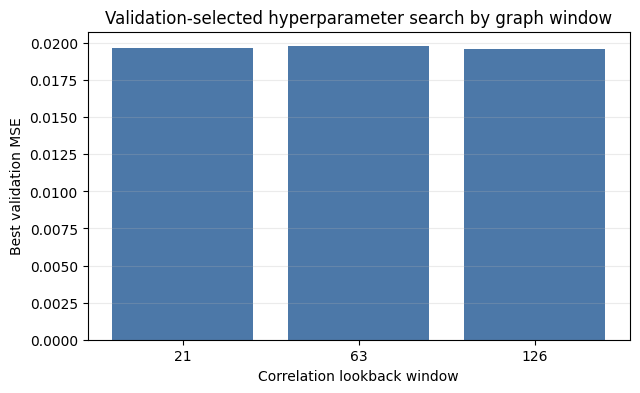

In [10]:
import matplotlib.pyplot as plt

if 'summary_df' in globals() and not summary_df.empty and 'best_val_mse' in summary_df.columns:
    plot_df = summary_df.loc[summary_df['status'].eq('ok')].copy()
    if not plot_df.empty:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(plot_df['window'].astype(str), plot_df['best_val_mse'], color='#4c78a8')
        ax.set_xlabel('Correlation lookback window')
        ax.set_ylabel('Best validation MSE')
        ax.set_title('Validation-selected hyperparameter search by graph window')
        ax.grid(axis='y', alpha=0.25)
        plt.show()
else:
    print('No completed summary available to plot yet.')


In [11]:
# Quick checkpoint sanity check on one validation week for every completed tuned window model.
sanity_rows = []
val_weeks = splits.loc[splits['split'] == 'val', 'week'].sort_values().reset_index(drop=True)
sample_week = val_weeks.iloc[min(25, len(val_weeks) - 1)]
sample_pos = list(week_index).index(sample_week)
x_sample = torch.tensor(features_3d[sample_pos], dtype=torch.float32).to(device)

for window in WINDOWS:
    if window not in window_best_configs:
        sanity_rows.append({'window': window, 'status': 'missing_best_config'})
        continue
    best_ckpt = CHECKPOINT_DIR / window_best_checkpoint_name(window)
    if not best_ckpt.exists():
        sanity_rows.append({'window': window, 'status': 'missing_checkpoint', 'checkpoint': best_ckpt.as_posix()})
        continue

    best_model = build_model_from_config(window_best_configs[window])
    best_model.load_state_dict(torch.load(best_ckpt, map_location=device, weights_only=True))
    best_model.eval()
    sample_ei = load_window_graphs(window, 'val').get(sample_week, torch.zeros(2, 0, dtype=torch.long)).to(device)
    with torch.no_grad():
        pred = best_model(x_sample, sample_ei)
    sanity_rows.append({
        'window': window,
        'status': 'ok',
        'sample_week': sample_week.date().isoformat(),
        'output_shape': tuple(pred.shape),
        'nan_count': int(pred.isnan().sum().item()),
        'pred_min': float(pred.min().item()),
        'pred_max': float(pred.max().item()),
        'parameters': int(sum(p.numel() for p in best_model.parameters())),
        'checkpoint': best_ckpt.as_posix(),
    })

sanity_df = pd.DataFrame(sanity_rows)
display(sanity_df)


C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(
C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(
C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:350: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


,window,status,sample_week,output_shape,nan_count,pred_min,pred_max,parameters,checkpoint
0,21,ok,2023-06-26,"(465,)",0,0.128424,0.493538,275201,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...
1,63,ok,2023-06-26,"(465,)",0,0.134614,0.504581,143105,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...
2,126,ok,2023-06-26,"(465,)",0,0.104201,0.430672,275201,C:/Users/Rylan Wade/Desktop/FinancialAnalytics...
